In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap
import plotly.express as px

print("pandas version:", pd.__version__)
print("numpy version:", np.__version__)
print("xgboost version:", xgb.__version__)
print("All imports successful! Ready to build!")

pandas version: 2.3.3
numpy version: 2.4.3
xgboost version: 3.2.0
All imports successful! Ready to build!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported!")

✅ All libraries imported!


In [10]:
import pandas as pd
import os

# Direct hardcoded path
BASE = r"C:\Users\Admin\Desktop\AI-Business-Risk-Intelligence"

telco = pd.read_csv(os.path.join(BASE, "data", "raw", "telco_churn.csv"))
print(f"✅ Telco loaded: {telco.shape[0]} rows, {telco.shape[1]} columns")

bank = pd.read_csv(os.path.join(BASE, "data", "raw", "bank_customers.csv"))
print(f"✅ Bank loaded: {bank.shape[0]} rows, {bank.shape[1]} columns")

ecommerce = pd.read_csv(os.path.join(BASE, "data", "raw", "ecommerce_customers.csv"))
print(f"✅ Ecommerce loaded: {ecommerce.shape[0]} rows, {ecommerce.shape[1]} columns")

print("\n🎉 All datasets loaded successfully!")

✅ Telco loaded: 7043 rows, 21 columns
✅ Bank loaded: 10000 rows, 14 columns
✅ Ecommerce loaded: 5630 rows, 20 columns

🎉 All datasets loaded successfully!


In [11]:
print("=" * 50)
print("TELCO DATASET - FIRST LOOK")
print("=" * 50)
print(f"\nShape: {telco.shape}")
print(f"\nColumns:\n{list(telco.columns)}")
print(f"\nFirst 5 rows:")
telco.head()

TELCO DATASET - FIRST LOOK

Shape: (7043, 21)

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [12]:
print("MISSING VALUES IN TELCO DATASET")
print("=" * 40)
missing = telco.isnull().sum()
print(missing[missing > 0])
print(f"\nTotal missing: {telco.isnull().sum().sum()}")

MISSING VALUES IN TELCO DATASET
Series([], dtype: int64)

Total missing: 0


CHURN DISTRIBUTION
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Rate: 26.54%


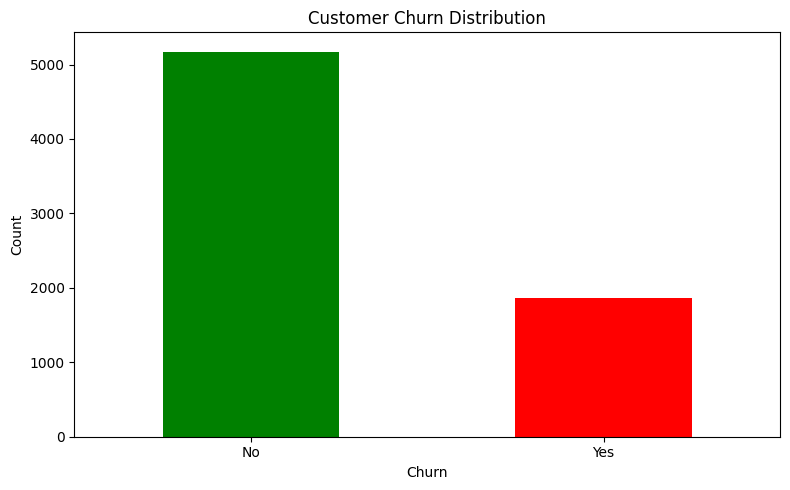

In [13]:
print("CHURN DISTRIBUTION")
print("=" * 40)
print(telco['Churn'].value_counts())
print(f"\nChurn Rate: {telco['Churn'].value_counts(normalize=True)['Yes']*100:.2f}%")

# Plot
plt.figure(figsize=(8,5))
telco['Churn'].value_counts().plot(kind='bar', color=['green','red'])
plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [14]:
print("=" * 50)
print("BANK DATASET - FIRST LOOK")
print("=" * 50)
print(f"\nShape: {bank.shape}")
print(f"\nColumns:\n{list(bank.columns)}")
print(f"\nChurn Distribution:")
print(bank['Exited'].value_counts())
print(f"\nChurn Rate: {bank['Exited'].value_counts(normalize=True)[1]*100:.2f}%")

BANK DATASET - FIRST LOOK

Shape: (10000, 14)

Columns:
['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Churn Distribution:
Exited
0    7963
1    2037
Name: count, dtype: int64

Churn Rate: 20.37%


In [15]:
print("=" * 50)
print("ECOMMERCE DATASET - FIRST LOOK")
print("=" * 50)
print(f"\nShape: {ecommerce.shape}")
print(f"\nColumns:\n{list(ecommerce.columns)}")

ECOMMERCE DATASET - FIRST LOOK

Shape: (5630, 20)

Columns:
['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier', 'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']


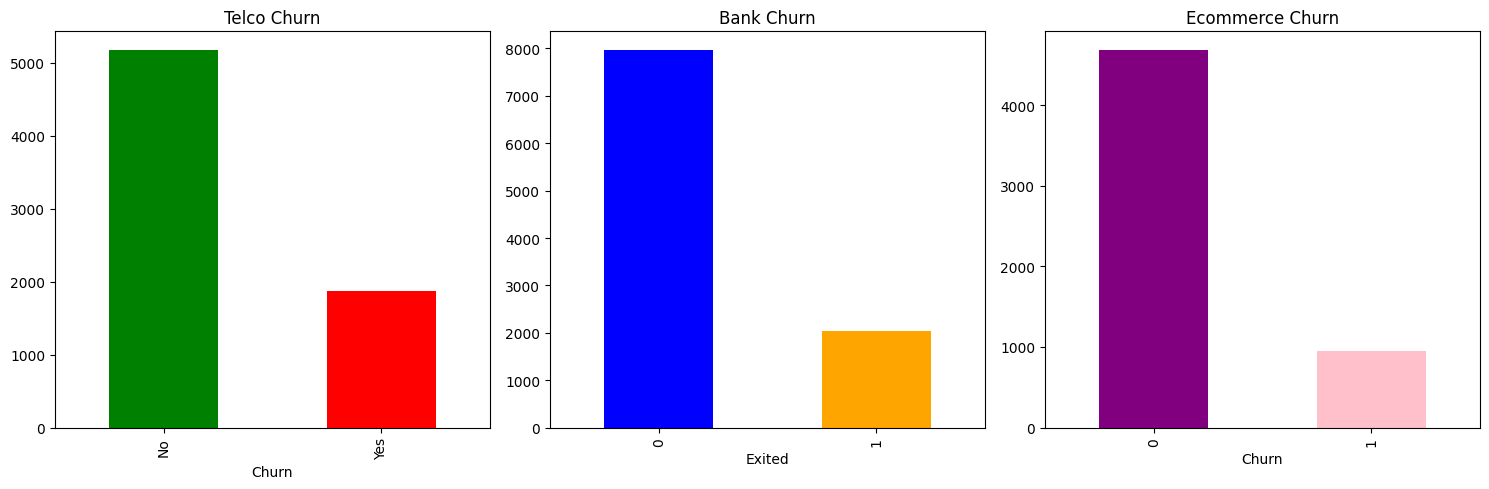

✅ Charts displayed!


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Telco
telco['Churn'].value_counts().plot(kind='bar', ax=axes[0], color=['green','red'])
axes[0].set_title('Telco Churn')
axes[0].set_xlabel('Churn')

# Bank
bank['Exited'].value_counts().plot(kind='bar', ax=axes[1], color=['blue','orange'])
axes[1].set_title('Bank Churn')
axes[1].set_xlabel('Exited')

# Ecommerce
ecommerce['Churn'].value_counts().plot(kind='bar', ax=axes[2], color=['purple','pink'])
axes[2].set_title('Ecommerce Churn')
axes[2].set_xlabel('Churn')

plt.tight_layout()
plt.show()
print("✅ Charts displayed!")

In [17]:
print("=" * 50)
print("DATASET SUMMARY")
print("=" * 50)

print(f"\n📊 TELCO: {telco.shape[0]} customers | Churn Rate: {(telco['Churn']=='Yes').mean()*100:.1f}%")
print(f"📊 BANK: {bank.shape[0]} customers | Churn Rate: {bank['Exited'].mean()*100:.1f}%")
print(f"📊 ECOMMERCE: {ecommerce.shape[0]} customers")

print("\n📋 TELCO Data Types:")
print(telco.dtypes)

DATASET SUMMARY

📊 TELCO: 7043 customers | Churn Rate: 26.5%
📊 BANK: 10000 customers | Churn Rate: 20.4%
📊 ECOMMERCE: 5630 customers

📋 TELCO Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [18]:
print("TELCO NUMERICAL STATISTICS")
print("=" * 50)
telco.describe()

TELCO NUMERICAL STATISTICS


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [19]:
print("=" * 50)
print("✅ WEEK 1 - DATA EXPLORATION COMPLETE!")
print("=" * 50)
print(f"\n📊 Telco: {telco.shape}")
print(f"📊 Bank: {bank.shape}")
print(f"📊 Ecommerce: {ecommerce.shape}")
print("\n🚀 Ready for Week 2 - Data Cleaning!")

✅ WEEK 1 - DATA EXPLORATION COMPLETE!

📊 Telco: (7043, 21)
📊 Bank: (10000, 14)
📊 Ecommerce: (5630, 20)

🚀 Ready for Week 2 - Data Cleaning!
